# EduLink  — Model 5: Education Path Recommendation
**Industry-Level | PySpark | Rule-Based Weighted Scoring | Coverage & Precision Validation**

**Pipeline:**
1. Load students + career clusters + institute catalog
2. Hard constraint filtering (budget, mode, duration)
3. Weighted scoring (cluster priority, budget alignment, level alignment)
4. Top-3 program recommendation per student
5. Validation: Coverage rate, Constraint satisfaction rate, Score distribution
6. Save results

In [1]:
# ─── CELL 1: Setup ───
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install -q pyspark
print("Ready.")


Mounted at /content/drive
Ready.


In [2]:
# ─── CELL 2: Spark ───
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

spark = (SparkSession.builder
         .appName("EDUCLINE-EduPath-v2")
         .config("spark.driver.memory","4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)


Spark: 4.0.2


In [3]:
# ─── CELL 3: Paths ───
import os

ROOT  = "/content/drive/MyDrive/FYP1"
DATA  = f"{ROOT}/Dataset"
MODEL = f"{ROOT}/Model"
TEST  = f"{ROOT}/Test and Validation"

STUDENTS_FILE = f"{DATA}/synthetic_exam_master_2000.csv"
CAREER_REPORT = f"{DATA}/career_fit_report.csv"
CATALOG_FILE  = f"{DATA}/institutes_catalog_v2.csv"
OUT_FOLDER    = f"{TEST}/education_report_csv"
FINAL_CSV     = f"{DATA}/education_report.csv"

for folder_path in [DATA, MODEL, TEST]:
    os.makedirs(folder_path, exist_ok=True)

for p in [STUDENTS_FILE, CAREER_REPORT, CATALOG_FILE]:
    print("EXISTS:", os.path.exists(p), "->", p)


EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/synthetic_exam_master_2000.csv
EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/career_fit_report.csv
EXISTS: True -> /content/drive/MyDrive/FYP1/Dataset/institutes_catalog_v2.csv


In [4]:
# ─── CELL 4: Load Data ───
students = spark.read.option("header",True).option("inferSchema",True).csv(STUDENTS_FILE)
career   = spark.read.option("header",True).option("inferSchema",True).csv(CAREER_REPORT)
catalog  = spark.read.option("header",True).option("inferSchema",True).csv(CATALOG_FILE)

print(f"Students: {students.count()} | Career: {career.count()} | Catalog: {catalog.count()}")
students.show(2,truncate=False)
catalog.printSchema()


Students: 2000 | Career: 2000 | Catalog: 261
+----------+-------+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+-------------------+--------------------+----------------+-------------------+----------------+----------------+-------------------+-------------+-----------------+-------------------+------------------------+---------------------+--------------------+-------------+---------------------------+------------------------+------------------+---------------------+----------------------------+---------------------------+----+-----------------+-----------------+-----------------+------------------+-----------------+-------------+
|student_id|persona|Q1 |Q2 |Q3 |Q4 |Q5 |Q6 |Q7 |Q8 |Q9 |Q10|Q11|Q12|Q13|Q14|Q15|Q16|Q17|Q18|Q19|Q20|Q21|Q22|Q23|Q24|Q25|Q26|Q27|Q28|Q29|Q30|Q31|Q32|Q33|Q34|Q35|Q36|Q37|Q38|Q39|Q40|Analytical_Thinking|Structure_Preference|Creativity_Index|Emotional

In [5]:
# ─── CELL 5: Prepare Student Data ───
# Rename career cluster columns
if "Top1" in career.columns:
    career = (career
              .withColumnRenamed("Top1","Top1_cluster")
              .withColumnRenamed("Top2","Top2_cluster")
              .withColumnRenamed("Top3","Top3_cluster"))

students2 = students.withColumn("orig_id", F.col("student_id").cast("string"))
career2   = career.withColumn("orig_id",   F.col("student_id").cast("string"))

df = (students2.join(
        career2.select("orig_id","Top1_cluster","Top2_cluster","Top3_cluster"),
        on="orig_id", how="left")
      .withColumn("Top1_cluster", F.coalesce(F.col("Top1_cluster"), F.lit("Software_Web_Engineering")))
      .withColumn("Top2_cluster", F.coalesce(F.col("Top2_cluster"), F.lit("Data_AI_Engineering")))
      .withColumn("Top3_cluster", F.coalesce(F.col("Top3_cluster"), F.lit("Business_IT_Management"))))

# Ensure preference columns exist
def ensure_col(d, col, default):
    return d if col in d.columns else d.withColumn(col, F.lit(default))

df = ensure_col(df, "budget",       "Medium")
df = ensure_col(df, "mode",         "Mixed")
df = ensure_col(df, "time_horizon", "Normal")
df = ensure_col(df, "level",        "AL")

# Clean sequential Student_ID
w_ord = Window.orderBy(F.col("orig_id").cast("long").asc_nulls_last())
df = df.withColumn("Student_ID", F.row_number().over(w_ord))

print(f"Prepared students: {df.count()}")
df.select("Student_ID","Top1_cluster","budget","mode","time_horizon","level").show(5,truncate=False)


Prepared students: 2000
+----------+-----------------------+------+-----+------------+-----+
|Student_ID|Top1_cluster           |budget|mode |time_horizon|level|
+----------+-----------------------+------+-----+------------+-----+
|1         |IT_Operations_QA       |Medium|Mixed|Normal      |AL   |
|2         |Data_AI_Engineering    |Medium|Mixed|Normal      |AL   |
|3         |Network_Infrastructure |Medium|Mixed|Normal      |AL   |
|4         |Digital_Marketing_Media|Medium|Mixed|Normal      |AL   |
|5         |Digital_Marketing_Media|Medium|Mixed|Normal      |AL   |
+----------+-----------------------+------+-----+------------+-----+
only showing top 5 rows


In [6]:
# ─── CELL 6: Prepare Catalog ───
required = ["program_id","institute","institute_location","program_cluster",
            "program_level","duration_months","cost_level","delivery_mode","min_english"]
missing  = [c for c in required if c not in catalog.columns]
if missing: raise Exception(f"Missing catalog columns: {missing}")

catalog2 = (catalog.select(
    F.col("program_id").cast("string"),
    "institute","institute_location","program_cluster","program_level",
    F.col("duration_months").cast("int"),
    "cost_level","delivery_mode","min_english"))

print(f"Programs in catalog: {catalog2.count()}")
catalog2.groupBy("program_level","cost_level").count().orderBy("program_level","cost_level").show()


Programs in catalog: 261
+-------------+----------+-----+
|program_level|cost_level|count|
+-------------+----------+-----+
|       Degree|      High|   57|
|      Diploma|    Medium|   84|
|          NVQ|       Low|   36|
|        Short|       Low|   84|
+-------------+----------+-----+



In [7]:
# ─── CELL 7: Candidate Generation ───
cand = (df.select(
            "Student_ID","Top1_cluster","Top2_cluster","Top3_cluster",
            "budget","mode","time_horizon","level",
            F.explode(F.array("Top1_cluster","Top2_cluster","Top3_cluster")).alias("cluster_key"))
        .join(catalog2, F.col("cluster_key")==F.col("program_cluster"), "inner")
        .drop("cluster_key"))

print(f"Candidate rows before filtering: {cand.count()}")


Candidate rows before filtering: 193275


In [8]:
# ─── CELL 8: Hard Constraint Filtering ───
cost_rank = F.create_map(F.lit("Low"),F.lit(1), F.lit("Medium"),F.lit(2), F.lit("High"),F.lit(3))

cand2 = (cand
    .withColumn("prog_cost_rank", cost_rank.getItem(F.col("cost_level")))
    .withColumn("stud_cost_rank", cost_rank.getItem(F.col("budget")))
    .withColumn("duration_ok",
        F.when(F.col("time_horizon")=="Fast", F.col("duration_months") <= 12)
         .otherwise(F.col("duration_months") <= 48))
    .withColumn("mode_ok",
        F.when(F.col("mode")=="Mixed", F.lit(True))
         .otherwise(F.col("delivery_mode")==F.col("mode"))))

filtered = cand2.where(
    (F.col("prog_cost_rank") <= F.col("stud_cost_rank")) &
    (F.col("duration_ok") == True) &
    (F.col("mode_ok")     == True))

total_students = df.count()
covered        = filtered.select("Student_ID").distinct().count()
coverage_rate  = covered / total_students * 100

print(f"After hard filters: {filtered.count()} rows")
print(f"Students covered: {covered}/{total_students} ({coverage_rate:.1f}%)")


/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


After hard filters: 154707 rows
Students covered: 2000/2000 (100.0%)


In [9]:
# ─── CELL 9: Weighted Scoring & Ranking ───
scored = (filtered
    .withColumn("cluster_weight",
        F.when(F.col("program_cluster")==F.col("Top1_cluster"), 3)
         .when(F.col("program_cluster")==F.col("Top2_cluster"), 2)
         .otherwise(1))
    .withColumn("budget_bonus",
        F.when((F.col("budget")=="Low")    & (F.col("cost_level")=="Low"),    3)
         .when((F.col("budget")=="Medium") & (F.col("cost_level")=="Medium"), 3)
         .when((F.col("budget")=="High")   & (F.col("cost_level")=="High"),   3)
         .when((F.col("budget")=="High")   & (F.col("cost_level")=="Medium"), 2)
         .otherwise(0))
    .withColumn("level_bonus",
        F.when((F.col("level")=="OL") & (F.col("program_level")=="Short"),   3)
         .when((F.col("level")=="OL") & (F.col("program_level")=="Diploma"), 2)
         .when((F.col("level")=="AL") & (F.col("program_level")=="Degree"),  3)
         .when((F.col("level")=="AL") & (F.col("program_level")=="Diploma"), 2)
         .otherwise(0))
    .withColumn("score_cluster",  F.col("cluster_weight") * 100)
    .withColumn("score_duration", (60 - F.col("duration_months")) * 0.2)
    .withColumn("tie_break",      (F.abs(F.hash(F.col("Student_ID"), F.col("program_id"))) % 1000) / 1000.0)
    .withColumn("total_score",
        F.col("score_cluster") +
        F.col("budget_bonus") * 5 +
        F.col("level_bonus")  * 5 +
        F.col("score_duration") +
        F.col("tie_break") * 0.01))

w = Window.partitionBy("Student_ID").orderBy(F.desc("total_score"))
ranked = scored.withColumn("rn", F.row_number().over(w)).where(F.col("rn") <= 3)

program_text = F.concat_ws("", F.lit("["), F.col("program_id"), F.lit("] "),
    F.col("program_level"), F.lit(" in "), F.col("program_cluster"),
    F.lit(" @ "), F.col("institute"), F.lit(" - "),
    F.col("delivery_mode"), F.lit(", "),
    F.col("duration_months").cast("string"), F.lit(" months, cost="),
    F.col("cost_level"))

ranked = ranked.withColumn("program_text", program_text)
programs = (ranked.groupBy("Student_ID").pivot("rn",[1,2,3]).agg(F.first("program_text"))
            .withColumnRenamed("1","program_1")
            .withColumnRenamed("2","program_2")
            .withColumnRenamed("3","program_3"))

print(f"Recommendations generated for {programs.count()} students")


Recommendations generated for 2000 students


=== Education Path Recommendation Validation ===
Total students with recommendations: 2000
Coverage rate:                       100.0%
Budget constraint satisfied:         100.0%
Duration constraint satisfied:       100.0%
Top-1 cluster match rate:            100.0%


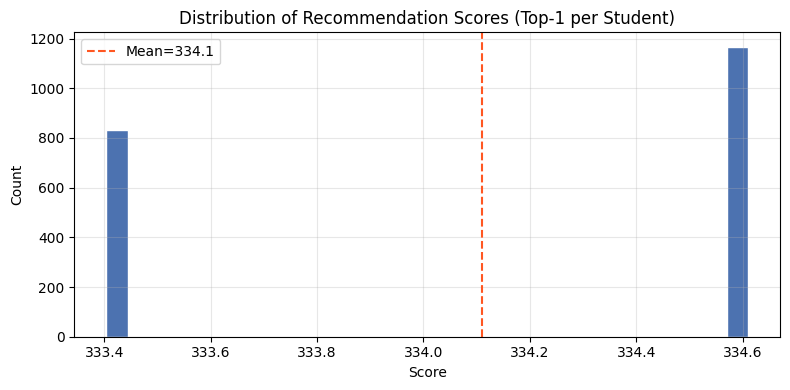

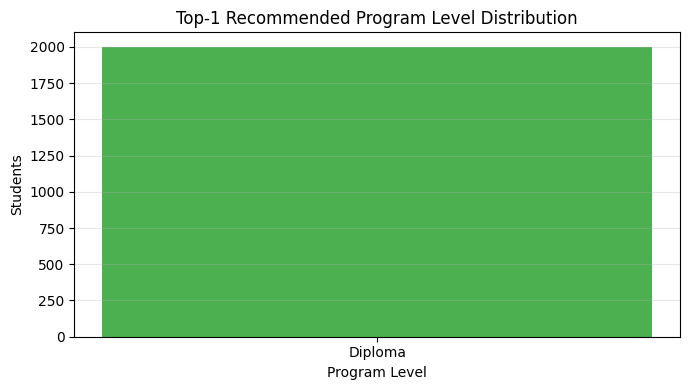

In [10]:
# ─── CELL 10: Validation Metrics ───
import matplotlib.pyplot as plt

# Constraint satisfaction: check how many top-1 recommendations pass all constraints
top1_check = ranked.where(F.col("rn")==1)
n_total    = top1_check.count()

# Budget constraint satisfied
budget_ok  = top1_check.where(F.col("prog_cost_rank") <= F.col("stud_cost_rank")).count()
# Duration constraint satisfied
dur_ok     = top1_check.where(F.col("duration_ok")==True).count()
# Cluster relevance: program matches Top1 cluster
top1_match = top1_check.where(F.col("program_cluster")==F.col("Top1_cluster")).count()

print("=== Education Path Recommendation Validation ===")
print(f"Total students with recommendations: {n_total}")
print(f"Coverage rate:                       {coverage_rate:.1f}%")
print(f"Budget constraint satisfied:         {budget_ok/n_total*100:.1f}%")
print(f"Duration constraint satisfied:       {dur_ok/n_total*100:.1f}%")
print(f"Top-1 cluster match rate:            {top1_match/n_total*100:.1f}%")

# Score distribution of top-1 recommendations
scores_pd = top1_check.select("total_score").toPandas()
plt.figure(figsize=(8,4))
plt.hist(scores_pd["total_score"], bins=30, color="#4C72B0", edgecolor="white")
plt.axvline(scores_pd["total_score"].mean(), color="#FF5722", linestyle="--",
            label=f"Mean={scores_pd['total_score'].mean():.1f}")
plt.title("Distribution of Recommendation Scores (Top-1 per Student)")
plt.xlabel("Score"); plt.ylabel("Count"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Program level distribution
level_pd = (ranked.where(F.col("rn")==1)
            .groupBy("program_level").count().toPandas())
plt.figure(figsize=(7,4))
plt.bar(level_pd["program_level"], level_pd["count"], color="#4CAF50")
plt.title("Top-1 Recommended Program Level Distribution")
plt.xlabel("Program Level"); plt.ylabel("Students"); plt.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
# ─── CELL 11: Build Final Report & Save ───
import os, glob, shutil

final_df = (df.select("Student_ID","Top1_cluster","Top2_cluster","Top3_cluster",
                       "budget","mode","time_horizon","level")
            .join(programs, on="Student_ID", how="left")
            .fillna({"program_1":"","program_2":"","program_3":""})
            .withColumn("path_step_1", F.lit("Step 1: Select one recommended program and enroll."))
            .withColumn("path_step_2", F.lit("Step 2: Follow the syllabus and complete all assessments."))
            .withColumn("path_step_3", F.lit("Step 3: Complete the qualification and progress to the next level.")))

os.makedirs(OUT_FOLDER, exist_ok=True)
(final_df.coalesce(1).write.mode("overwrite").option("header",True).csv(OUT_FOLDER))
parts = glob.glob(OUT_FOLDER + "/part-*.csv")
if parts:
    shutil.copy(parts[0], FINAL_CSV)
    print("Saved:", FINAL_CSV)

final_df.show(5, truncate=False)
print(f"Education report rows: {final_df.count()}")


Saved: /content/drive/MyDrive/FYP1/Dataset/education_report.csv
+----------+-----------------------+-----------------------+-----------------------+------+-----+------------+-----+---------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------+--------------------------------------------------+---------------------------------------------------------+------------------------------------------------------------------+
|Student_ID|Top1_cluster           |Top2_cluster           |Top3_cluster           |budget|mode |time_horizon|level|program_1                                                                              |program_2                                                                                 |program_3                                                                        |path_